# Attempt on video classification

Directories

In [ ]:
from pathlib import Path
import shutil
import random
import os

# Source folder: ~/Documents/vid_dataset/
base_path = Path.home() / "Documents" / "vid_dataset" / "raw_vids"

# Destination folders
train_path = Path.home() / "Documents" /  "vid_dataset" / "split" / "train"
val_path = Path.home() / "Documents" /  "vid_dataset" / "split" / "val"

# Class names = folder names
classes = ["starlight", "wave", "spectrum_cycling"]

# Train/Val ratio
train_ratio = 0.8

# Create output directories
for split_path in [train_path, val_path]:
    for cls in classes:
        os.makedirs(split_path / cls, exist_ok=True)

# Split and copy files
for cls in classes:
    class_dir = base_path / cls
    video_files = list(class_dir.glob("*.mp4"))
    random.shuffle(video_files)

    train_count = int(len(video_files) * train_ratio)
    train_videos = video_files[:train_count]
    val_videos = video_files[train_count:]

    for vid in train_videos:
        shutil.copy(vid, train_path / cls / vid.name)
    for vid in val_videos:
        shutil.copy(vid, val_path / cls / vid.name)

In [1]:
from pathlib import Path

# Source folder: ~/Documents/vid_dataset/
base_path = Path.home() / "Documents" / "vid_dataset" / "raw_vids"

# Destination folders
train_path = Path.home() / "Documents" /  "vid_dataset" / "split" / "train"
val_path = Path.home() / "Documents" /  "vid_dataset" / "split" / "val"

# Class names = folder names
classes = ["starlight", "wave", "spectrum_cycling"]

Extracting Videos

In [11]:
import cv2
import numpy as np

def extract_frames(video_path, frame_count=90, target_size=(112, 112)):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while len(frames) < frame_count and cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, target_size)
        frame = frame / 255.0
        frames.append(frame)
    cap.release()
    
    # Pad or truncate to exactly `frame_count` frames
    if len(frames) < frame_count:
        frames += [np.zeros_like(frames[0])] * (frame_count - len(frames))
    return np.array(frames)


Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Flatten, Dense, Dropout, GlobalAveragePooling3D

def build_conv_lstm(input_shape=(90, 112, 112, 3), num_classes=3):
    model = Sequential([
        ConvLSTM2D(filters=16, kernel_size=(3,3),
                input_shape=input_shape,
                return_sequences=False, activation='relu'),
        BatchNormalization(),
        GlobalAveragePooling3D(),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy'])
    return model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Dropout

def build_cnn_lstm1(input_shape=(90, 112, 112, 3), num_classes=3):
    model = Sequential([
        TimeDistributed(Conv2D(16, (3,3), activation='relu'), input_shape=input_shape),
        TimeDistributed(MaxPooling2D(pool_size=(2,2))),
        TimeDistributed(Conv2D(32, (3,3), activation='relu')),
        TimeDistributed(MaxPooling2D(pool_size=(2,2))),
        TimeDistributed(Flatten()),
        LSTM(64),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [86]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, LSTM, Dense, Dropout, GlobalAveragePooling2D
import tensorflow as tf

def build_cnn_lstm2(input_shape=(90, 112, 112, 3), num_classes=3):
    model = Sequential([
        TimeDistributed(Conv2D(8, (3,3), activation='relu', padding='same'), input_shape=input_shape),
        TimeDistributed(MaxPooling2D((2,2))),
        TimeDistributed(Conv2D(16, (3,3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2,2))),
        TimeDistributed(tf.keras.layers.Flatten()),
        LSTM(32),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, LSTM, Dense, Dropout
import tensorflow as tf

def build_cnn_lstm3(input_shape=(90, 112, 112, 3), num_classes=3):
    model = Sequential([
        TimeDistributed(Conv2D(8, (3,3), activation='relu', padding='same'), input_shape=input_shape),
        TimeDistributed(MaxPooling2D((2,2))),
        TimeDistributed(Conv2D(16, (3,3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2,2))),
        TimeDistributed(Conv2D(32, (3,3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2,2))),
        TimeDistributed(tf.keras.layers.Flatten()),
        LSTM(32),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [129]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, LSTM, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, Bidirectional
import tensorflow as tf

def build_cnn_lstm4(input_shape=(90, 112, 112, 3), num_classes=3):
    model = Sequential([
        TimeDistributed(Conv2D(8, (3,3), activation='relu', padding='same'), input_shape=input_shape),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2,2))),

        TimeDistributed(Conv2D(16, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2,2))),

        TimeDistributed(Conv2D(32, (3,3), activation='relu', padding='same')),
        # TimeDistributed(BatchNormalization()),
        TimeDistributed(MaxPooling2D((2,2))),

        TimeDistributed(tf.keras.layers.Flatten()),

        Bidirectional(LSTM(64)),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2), metrics=['accuracy'])
    return model


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, LSTM, Dense, Dropout, Bidirectional
import tensorflow as tf

def build_cnn_lstm5(input_shape=(90, 112, 112, 3), num_classes=3):
    model = Sequential([
        TimeDistributed(Conv2D(8, (3,3), activation='relu', padding='same'), input_shape=input_shape),
        TimeDistributed(MaxPooling2D((2,2))),
        TimeDistributed(Conv2D(16, (3,3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2,2))),
        TimeDistributed(Conv2D(32, (3,3), activation='relu', padding='same')),
        TimeDistributed(MaxPooling2D((2,2))),
        TimeDistributed(tf.keras.layers.Flatten()),
        Bidirectional(LSTM(64)),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), metrics=['accuracy'])
    return model


In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Flatten, Dense, Dropout, GlobalAveragePooling3D

def build_conv_lstm(input_shape=(90, 112, 112, 3), num_classes=3):
    model = Sequential()

    # ConvLSTM expects shape: (timesteps, height, width, channels)
    model.add(ConvLSTM2D(filters=16, kernel_size=(3, 3),
                         activation='relu',
                         input_shape=input_shape,
                         return_sequences=True))
    model.add(BatchNormalization())

    model.add(ConvLSTM2D(filters=64, kernel_size=(3, 3),
                         activation='relu',
                         return_sequences=False))
    model.add(BatchNormalization())

    model.add(GlobalAveragePooling3D())
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model


Labelling

In [41]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

labels = ["starlight", "wave", "spectrum_cycling"]
le = LabelEncoder()
y_encoded = le.fit_transform(labels)
y_cat = to_categorical(y_encoded)

Augmentation

In [5]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from pathlib import Path
import albumentations as A


class OnTheFlyVideoGenerator(Sequence):
    def __init__(self, data_dir, class_names, frame_count=90, target_size=(112, 112), batch_size=4, shuffle=True, augment=False):
        self.data_dir = Path(data_dir)
        self.class_names = class_names
        self.frame_count = frame_count
        self.target_size = target_size
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.video_paths = []
        self.labels = []
        self.augment = augment
        self.frame_aug = A.Compose([
            A.RandomBrightnessContrast(p=0.5),
            A.HorizontalFlip(p=0.5),
            A.Rotate(limit=10, p=0.3),
            A.HueSaturationValue(p=0.4),
        ])

        for idx, class_name in enumerate(class_names):
            for video_file in (self.data_dir / class_name).glob("*.mp4"):
                self.video_paths.append(video_file)
                self.labels.append(idx)

        self.indices = np.arange(len(self.video_paths))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.video_paths) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_x, batch_y = [], []
        for i in batch_indices:
            video_path = self.video_paths[i]
            frames = self.load_video_frames(video_path)
            batch_x.append(frames)
            batch_y.append(self.labels[i])
        return np.array(batch_x), tf.keras.utils.to_categorical(batch_y, num_classes=len(self.class_names))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def load_video_frames(self, video_path):
        cap = cv2.VideoCapture(str(video_path))
        frames = []
        while len(frames) < self.frame_count and cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.resize(frame, self.target_size)
            if self.augment:
                frame = self.frame_aug(image=frame)["image"]
            frame = frame / 255.0
            frames.append(frame)
        cap.release()
        if len(frames) < self.frame_count:
            pad_frame = np.zeros((self.target_size[1], self.target_size[0], 3))
            frames += [pad_frame] * (self.frame_count - len(frames))
        elif len(frames) > self.frame_count:
            frames = frames[:self.frame_count]  # Trim if needed
        return np.array(frames)


C:\Users\Yin Yu\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
class_names = ["starlight", "wave", "spectrum_cycling"]

train_gen = OnTheFlyVideoGenerator(
    data_dir=Path.home() / "Documents" / "vid_dataset" / "split" / "train",
    class_names=class_names,
    augment=True
)

val_gen = OnTheFlyVideoGenerator(
    data_dir=Path.home() / "Documents" / "vid_dataset" / "split" / "val",
    class_names=class_names,
    augment=False
)


Train

In [130]:
import tensorflow as tf
from sklearn.utils import class_weight
import os
import json
from pathlib import Path
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# model = build_cnn_lstm()
# model = build_conv_lstm()
# model = build_cnn_lstm2()
# model = build_cnn_lstm3()
model = build_cnn_lstm4()

base_path = Path.cwd().resolve().parents[1]
checkpoint_path = base_path / "models" / "checkpoints" / "video_model.h5"
final_model_path = base_path / "models" / "video_recognition" / "video_model4.h5"
metrics_path = base_path / "metrics" / "video_recognition"
metrics_path.mkdir(parents=True, exist_ok=True) 

checkpoint_cb = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False
)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Compute class weights from train_gen
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.labels),
    y=train_gen.labels
)
class_weights_dict = dict(enumerate(class_weights))

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights_dict,
    callbacks=[checkpoint_cb, early_stopping]
)

# === Evaluate Best Model ===
best_refined_model = tf.keras.models.load_model(checkpoint_path)
val_loss, val_accuracy = best_refined_model.evaluate(val_gen)
print(f"Best Validation Loss: {val_loss:.4f}")
print(f"Best Validation Accuracy: {val_accuracy:.4f}")

# === Save Final Model and Metrics ===
best_refined_model.save(final_model_path)
with open(metrics_path / "video_model4.json", "w") as f:
    json.dump(history.history, f)

Epoch 1/15
38/38 [==============================] - 125s 3s/step - loss: 0.9425 - accuracy: 0.5960 - val_loss: 0.7508 - val_accuracy: 0.6575
Epoch 2/15
38/38 [==============================] - 148s 4s/step - loss: 0.8250 - accuracy: 0.6159 - val_loss: 0.7584 - val_accuracy: 0.6849
Epoch 3/15
38/38 [==============================] - 145s 4s/step - loss: 0.7840 - accuracy: 0.7152 - val_loss: 0.7470 - val_accuracy: 0.6849
Epoch 4/15
38/38 [==============================] - 145s 4s/step - loss: 0.7575 - accuracy: 0.7285 - val_loss: 0.7190 - val_accuracy: 0.7260
Epoch 5/15
38/38 [==============================] - 150s 4s/step - loss: 0.7485 - accuracy: 0.7682 - val_loss: 0.6711 - val_accuracy: 0.8493
Epoch 6/15
38/38 [==============================] - 96s 3s/step - loss: 0.6979 - accuracy: 0.8079 - val_loss: 0.6937 - val_accuracy: 0.7397
Epoch 7/15
38/38 [==============================] - 97s 3s/step - loss: 0.7546 - accuracy: 0.7815 - val_loss: 0.6822 - val_accuracy: 0.7945
Epoch 8/15
38/3

Evaluation

In [11]:
from tensorflow.keras.models import load_model

base_path = Path.cwd().resolve().parents[1]
model_path = base_path / "models" / "video_recognition" / "video_model4.h5"
model = load_model(model_path)

sample_x, sample_y = val_gen[0]
preds = model.predict(sample_x)
print("True:", sample_y.argmax(axis=1))
print("Pred:", preds.argmax(axis=1))

1/1 [==============================] - 1s 1s/step
True: [1 0 0 1]
Pred: [1 0 0 1]


Test

In [7]:
test_gen = OnTheFlyVideoGenerator(
    data_dir=Path.home() / "Documents" / "vid_dataset" / "split" / "test",
    class_names=["starlight", "wave", "spectrum_cycling"],
    shuffle=False  # disable shuffling so predictions align with files
)

Predict

In [12]:
all_preds = []
all_labels = []

for i in range(len(test_gen)):
    x_batch, y_batch = test_gen[i]
    batch_preds = model.predict(x_batch)
    all_preds.extend(batch_preds.argmax(axis=1))
    all_labels.extend(y_batch.argmax(axis=1))

1/1 [==============================] - 0s 39ms/step


Evaluate Accuracy

In [13]:
from sklearn.metrics import accuracy_score, classification_report

print("Test Accuracy:", accuracy_score(all_labels, all_preds))
print("\nDetailed Report:\n", classification_report(all_labels, all_preds, target_names=test_gen.class_names))


Test Accuracy: 0.875

Detailed Report:
                   precision    recall  f1-score   support

       starlight       1.00      1.00      1.00         3
            wave       0.75      1.00      0.86         3
spectrum_cycling       1.00      0.50      0.67         2

        accuracy                           0.88         8
       macro avg       0.92      0.83      0.84         8
    weighted avg       0.91      0.88      0.86         8



In [135]:
for i, pred in enumerate(all_preds):
    if pred == 2:
        print(f"✅ Predicted class 2 → {test_gen.video_paths[i].name}")

✅ Predicted class 2 → test_8.mp4


In [31]:
from collections import Counter
print(Counter(test_gen.labels))

Counter({0: 3, 1: 3, 2: 2})


In [136]:
for path in test_gen.video_paths:
    if "spectrum_cycling" in str(path):
        print("Found test file:", path.name)

Found test file: test_7.mp4
Found test file: test_8.mp4


In [137]:
for i, path in enumerate(test_gen.video_paths):
    if "spectrum_cycling" in str(path):
        frames = test_gen.load_video_frames(path)
        pred_probs = best_refined_model.predict(np.expand_dims(frames, axis=0))[0]
        print(f"{path.name} → {pred_probs} → Predicted: {test_gen.class_names[np.argmax(pred_probs)]}")


1/1 [==============================] - 0s 21ms/step
test_7.mp4 → [0.09733595 0.7416809  0.16098316] → Predicted: wave
1/1 [==============================] - 0s 20ms/step
test_8.mp4 → [0.04540774 0.04163632 0.91295594] → Predicted: spectrum_cycling


In [142]:
for i, path in enumerate(val_gen.video_paths):
    if "spectrum_cycling" in str(path):
        frames = val_gen.load_video_frames(path)
        pred_probs = model.predict(np.expand_dims(frames, axis=0))[0]
        print(f"{path.name} → {pred_probs} → Predicted: {val_gen.class_names[np.argmax(pred_probs)]}")

1/1 [==============================] - 0s 22ms/step
spectrum_cycling_10.mp4 → [0.03986412 0.03680462 0.9233312 ] → Predicted: spectrum_cycling
1/1 [==============================] - 0s 25ms/step
spectrum_cycling_11.mp4 → [0.04013264 0.04762028 0.91224706] → Predicted: spectrum_cycling
1/1 [==============================] - 0s 22ms/step
spectrum_cycling_16.mp4 → [0.04137357 0.04507721 0.9135492 ] → Predicted: spectrum_cycling
1/1 [==============================] - 0s 21ms/step
spectrum_cycling_17.mp4 → [0.03931273 0.02968762 0.9309996 ] → Predicted: spectrum_cycling
1/1 [==============================] - 0s 21ms/step
spectrum_cycling_19.mp4 → [0.042813   0.05728787 0.8998992 ] → Predicted: spectrum_cycling
1/1 [==============================] - 0s 21ms/step
spectrum_cycling_2.mp4 → [0.04058765 0.05061169 0.90880066] → Predicted: spectrum_cycling
1/1 [==============================] - 0s 23ms/step
spectrum_cycling_20.mp4 → [0.03929505 0.04610748 0.9145975 ] → Predicted: spectrum_cycling


In [143]:
for i, path in enumerate(val_gen.video_paths):
    if "wave" in str(path):
        frames = val_gen.load_video_frames(path)
        pred_probs = model.predict(np.expand_dims(frames, axis=0))[0]
        print(f"{path.name} → {pred_probs} → Predicted: {val_gen.class_names[np.argmax(pred_probs)]}")

1/1 [==============================] - 0s 24ms/step
wave (1).mp4 → [0.05802663 0.8478196  0.09415372] → Predicted: wave
1/1 [==============================] - 0s 21ms/step
wave (11).mp4 → [0.06604808 0.76905835 0.1648936 ] → Predicted: wave
1/1 [==============================] - 0s 23ms/step
wave (12).mp4 → [0.05969918 0.79545337 0.14484747] → Predicted: wave
1/1 [==============================] - 0s 32ms/step
wave (14).mp4 → [0.06189011 0.817124   0.12098584] → Predicted: wave
1/1 [==============================] - 0s 23ms/step
wave (15).mp4 → [0.06611197 0.7498657  0.18402232] → Predicted: wave
1/1 [==============================] - 0s 21ms/step
wave (18).mp4 → [0.05918228 0.8374787  0.103339  ] → Predicted: wave
1/1 [==============================] - 0s 23ms/step
wave (23).mp4 → [0.05854732 0.8483607  0.09309197] → Predicted: wave
1/1 [==============================] - 0s 22ms/step
wave (31).mp4 → [0.05119517 0.8654334  0.08337133] → Predicted: wave
1/1 [============================

In [18]:
for i, path in enumerate(val_gen.video_paths):
    if "starlight" in str(path):
        frames = val_gen.load_video_frames(path)
        pred_probs = model.predict(np.expand_dims(frames, axis=0))[0]
        print(f"{path.name} → {pred_probs} → Predicted: {val_gen.class_names[np.argmax(pred_probs)]}")

1/1 [==============================] - 0s 54ms/step
starlight_1.mp4 → [0.9956204  0.00242465 0.00195491] → Predicted: starlight
1/1 [==============================] - 0s 43ms/step
starlight_11.mp4 → [0.9945966  0.00254714 0.00285625] → Predicted: starlight
1/1 [==============================] - 0s 44ms/step
starlight_12.mp4 → [0.994649   0.00252434 0.00282659] → Predicted: starlight
1/1 [==============================] - 0s 36ms/step
starlight_18.mp4 → [0.99475914 0.0024732  0.00276761] → Predicted: starlight
1/1 [==============================] - 0s 38ms/step
starlight_19.mp4 → [0.9947378  0.00247176 0.00279042] → Predicted: starlight
1/1 [==============================] - 0s 63ms/step
starlight_2.mp4 → [0.9956241  0.00242143 0.00195448] → Predicted: starlight
1/1 [==============================] - 0s 46ms/step
starlight_28.mp4 → [0.99450487 0.0025554  0.00293967] → Predicted: starlight
1/1 [==============================] - 0s 51ms/step
starlight_30.mp4 → [0.99450976 0.00255423 0.002

In [96]:
for i, path in enumerate(test_gen.video_paths):
    if "wave" in str(path):
        frames = test_gen.load_video_frames(path)
        prob = model.predict(np.expand_dims(frames, axis=0))[0]
        print(f"{path.name} → {np.round(prob, 3)} → Predicted: {test_gen.class_names[np.argmax(prob)]}")


1/1 [==============================] - 0s 19ms/step
test_4.mp4 → [0.002 0.659 0.339] → Predicted: wave
1/1 [==============================] - 0s 21ms/step
test_5.mp4 → [0.002 0.632 0.366] → Predicted: wave
1/1 [==============================] - 0s 20ms/step
test_6.mp4 → [0.002 0.624 0.374] → Predicted: wave


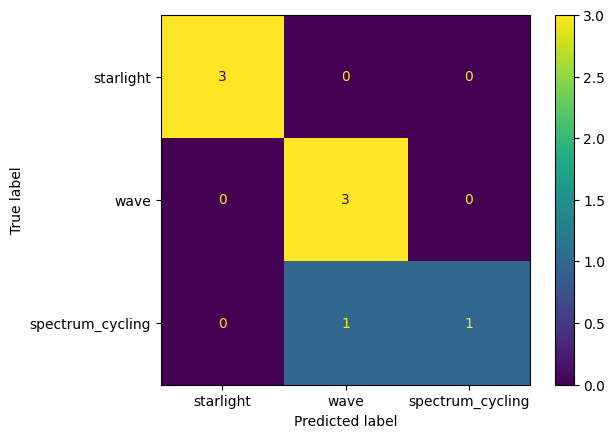

In [138]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=test_gen.class_names).plot()

In [47]:
import numpy as np
from pathlib import Path
from tensorflow.keras.models import load_model

model_path = base_path / "models" / "video_recognition" / "video_model4.h5"
model = load_model(model_path)

# Robot/pictures/testt_1.mp4
# C:\Users\Yin Yu\Documents\cv_automation\Robot\pictures\MicrosoftTeams-video (1).mp4
path = Path(r"C:\Users\Yin Yu\Documents\cv_automation\Robot\pictures\MicrosoftTeams-video (2).mp4")

# Load and preprocess frames
frames = test_gen.load_video_frames(path)
print("Input shape:", frames.shape)  # Debug

# Expand dims for batch
input_tensor = np.expand_dims(frames, axis=0)  # (1, 90, 112, 112, 3)

# Predict
pred_probs = model.predict(input_tensor)[0]

# Output
print(f"{path.name} → {pred_probs}")
print("Class Probabilities:")
for i, prob in enumerate(pred_probs):
    print(f"{test_gen.class_names[i]}: {prob:.4f}")

print(f"Predicted Class: {test_gen.class_names[np.argmax(pred_probs)]}")

Input shape: (90, 112, 112, 3)
1/1 [==============================] - 0s 383ms/step
MicrosoftTeams-video (2).mp4 → [0.5603561  0.32140455 0.11823941]
Class Probabilities:
starlight: 0.5604
wave: 0.3214
spectrum_cycling: 0.1182
Predicted Class: starlight


Random test codes

In [ ]:
frames = extract_frames(Path.home() / "Documents" / "vid_dataset" / "split" / "test")
frames = np.expand_dims(frames, axis=0)  # shape: (1, 30, size, size, 3)
prediction = model.predict(frames)
predicted_class = le.inverse_transform([np.argmax(prediction)])
print("Predicted Pattern:", predicted_class[0])

In [18]:
import tensorflow as tf
print("GPUs Available:", tf.config.list_physical_devices('GPU'))

from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 4111377547723303316
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 5833228288
locality {
  bus_id: 1
  links {
  }
}
incarnation: 10480032718416375726
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9"
xla_global_id: 416903419
]
